<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/06-logistic-regression-customer-churn/%D0%9B%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Работа 4

Цель лабораторной:

Научиться предсказывать вероятность оттока клиента (Churn) с помощью логистической регрессии, а также понять влияние признаков на вероятность оттока, оценить качество модели через accuracy, confusion matrix и визуализировать результат.

| Столбец                                                                                   | Описание                                           |
| ----------------------------------------------------------------------------------------- | -------------------------------------------------- |
| customerID                                                                                | уникальный идентификатор клиента                   |
| gender                                                                                    | пол клиента (Male/Female)                          |
| SeniorCitizen                                                                             | 1 если пожилой, 0 иначе                            |
| Partner                                                                                   | есть ли партнёр (Yes/No)                           |
| Dependents                                                                                | есть ли иждивенцы (Yes/No)                         |
| tenure                                                                                    | количество месяцев, как клиент пользуется услугами |
| PhoneService                                                                              | есть ли телефонная услуга (Yes/No)                 |
| MultipleLines                                                                             | есть ли несколько линий (Yes/No/No phone service)  |
| InternetService                                                                           | тип интернета (DSL/Fiber optic/No)                 |
| OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies | услуги (Yes/No/No internet service)                |
| Contract                                                                                  | тип контракта (Month-to-month/One year/Two year)   |
| PaperlessBilling                                                                          | использование электронного счёта (Yes/No)          |
| PaymentMethod                                                                             | способ оплаты                                      |
| MonthlyCharges                                                                            | ежемесячный платёж                                 |
| TotalCharges                                                                              | общий платёж                                       |
| Churn                                                                                     | ушёл ли клиент (Yes/No) — целевая переменная       |


In [ ]:
import pandas as pd
data_path = 'https://frenzy86.s3.eu-west-2.amazonaws.com/fav/churn.csv'
df = pd.read_csv(data_path)

Шаг 1. Изучите данные

Просмотрите типы столбцов, проверьте пропуски.

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Шаг 2. Преобразование целевой переменной и признаков

Churn содержит значения Yes/No.
Преобразуйте в числовой вид: Yes=1, No=0.

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Столбец customerID не несёт информации для модели, его можно удалить.

In [ ]:
df = df.drop('customerID', axis=1)
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


Столбец 'TotalCharges'имеет тип данных object, хотя должен быть числовым, выполним преобразование.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_7615/266577964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Шаг 3. Преобразование категорияальных признаков

Все признаки, кроме Churn, можно использовать.
Категориальные признаки нужно преобразовать в числа.

Пояснение:
Логистическая регрессия работает только с числами.
Категориальные признаки (например gender, Contract) нельзя подавать как строки.


Расскажите про функцию get_dummies.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

get_dummies превращает каждый текстовый столбец в набор числовых столбцов-флагов (1 или 0)

Шаг 4. Разделите данные на признаки и целевую переменную, а затем на  обучающую и тестовую выборки.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Шаг 5. Выполните масштабирование признаков tenure, MonthlyCharges, TotalCharges

Сейчас признаки лежат в разных диапазонах:

tenure ~ 0–72

MonthlyCharges ~ 20–120

TotalCharges ~ 20–9000

In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure','MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Объясните для чего используется масштабирование, fit_transform и transform.

Признак с большими числами (TotalCharges ~ 9000) будет доминировать над признаками с маленькими числами (tenure ~ 72). Модель подумает, что TotalCharges важнее, просто потому что его числа больше, а не потому что он действительно влияет на отток. Масштабирование приводит все признаки к одному диапазону от -2 до +2

Шаг 6. Обучите модель логистической регрессии, оцените точность, постройте матрицу ошибок

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.2%}")
print(f"Количество правильных ответов: {accuracy * len(y_test):.0f} из {len(y_test)}\n")

Точность модели: 80.55%
Количество правильных ответов: 1135 из 1409



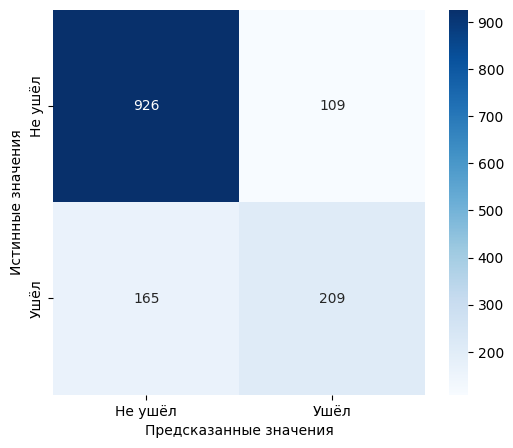

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Не ушёл', 'Ушёл'], yticklabels=['Не ушёл', 'Ушёл'])
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.show()

Шаг 7. Оцените влияние коэффициентов, как они влияют на выходной показатель?

In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coeff_df.head(10))

                           Feature  Coefficient
10     InternetService_Fiber optic     1.190576
3                     TotalCharges     0.511378
23             StreamingMovies_Yes     0.380384
21                 StreamingTV_Yes     0.378872
28  PaymentMethod_Electronic check     0.377641
26            PaperlessBilling_Yes     0.371600
9                MultipleLines_Yes     0.365301
0                    SeniorCitizen     0.144638
29      PaymentMethod_Mailed check     0.067582
17            DeviceProtection_Yes     0.037562


Больше >0,5 сильное влияние. Оптоволокно влияет больше всего в негативном ключе

Ваш ответ: